# C5. 평가셋 라벨링 방법론

| | |
|---|---|
| **트랙** | C 평가 |
| **선수 토픽** | C1, C4 |
| **프로젝트 앵커** | 52문항 병합셋 · gt 8건 교정 · 팀 라벨 병합 · natural query 자연화 |
| **작성일** | 2026-07-29 |
| **최종 검증** | 2026-07-29 |
| **상태** | 검증완료 |

## 한 줄 요약
> gold는 관측된 사실이 아니라 사람이 내린 판단이며, 그 판단을 합치는 규칙과 거기 섞인
> 오류율이 어떤 지표를 고르느냐보다 결과를 크게 바꾼다.

## 0. 준비

필요 패키지는 `numpy`, `matplotlib` 뿐이다. 라벨링은 사람의 판단이 개입하는 과정이라 실제
어노테이션 로그 없이는 재현할 수 없어 보이지만, 어노테이터를 **민감도와 특이도를 가진 잡음 있는
판정기**로 모델링하면 병합 규칙과 오류율의 효과는 전부 계산된다. §4는 그 모델 위에서 돈다.

In [1]:
# ── 표준 셋업 ────────────────────────────────────────────
from __future__ import annotations

import pathlib
import random
from collections import Counter

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ASSETS = pathlib.Path("../assets")
OUT = pathlib.Path("./out"); OUT.mkdir(exist_ok=True)
np.set_printoptions(precision=4, suppress=True)

# 팔레트 (FUNDAMENTAL 시리즈 공용)
C_MAIN, C_SUB, C_GRAY = "#ee4c2c", "#0d9488", "#94a3b8"

_installed = {f.name for f in fm.fontManager.ttflist}
for _f in ("AppleGothic", "Malgun Gothic", "NanumGothic"):
    if _f in _installed:
        mpl.rcParams["font.family"] = _f
        break
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["figure.figsize"] = (7, 4)
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.25
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False

print(f"seed={SEED} · font={mpl.rcParams['font.family'][0]}")

seed=42 · font=NanumGothic


## 1. 개념

### gold는 관측이 아니라 판단이다

hit@3를 계산할 때 우리는 gold를 고정된 사실처럼 다룬다. 실제로는 사람이 청크를 읽고 "이게
이 질문의 답이다"라고 결정한 결과이며, 그 결정에는 오류율과 개인차가 있다. C1이 지표를,
C4가 질의를 의심했다면 C5는 **분모 쪽 라벨 자체**를 의심한다.

### 라벨 오류는 점수를 낮추기만 하는 게 아니다

gold가 잘못 달린 문항에서 시스템은 엉뚱한 청크를 맞혀야 하므로 사실상 우연에 맡겨진다.
오류율 $e$, 진짜 성능 $s$, 오라벨 문항에서의 우연 적중률 $q$에 대해

> **정의**  라벨 오류가 섞인 평가셋에서 관측되는 점수는
> $$\text{관측} = (1-e)\,s + e\,q$$
> 이며, 두 시스템의 격차는 $(1-e)(s_1 - s_2)$ 로 **압축된다**.

두 번째 항이 더 위험하다. 라벨 오류는 모든 시스템의 점수를 비슷하게 끌어내리므로 "우리 점수가
낮게 나왔네" 정도로 넘어가기 쉽지만, 그 사이 A/B 판정에 필요한 격차가 함께 줄어든다. 개선을
감지하지 못하는 평가셋이 되는 것이다.

### 일치도를 raw agreement로 재면 안 된다

검색 라벨링은 후보 대부분이 오답인 희소 과제다. 두 어노테이터가 아무 생각 없이 전부 "아니다"에
표시해도 일치율은 97%가 나온다. 우연 일치를 빼야 의미가 생긴다.

> **정의**  Cohen's kappa는 관측 일치율 $p_o$에서 우연 일치율 $p_e$를 제거한다.
> $$\kappa = \frac{p_o - p_e}{1 - p_e}$$
> $p_e$는 두 어노테이터의 주변 분포가 독립일 때의 일치 확률이다.

### 병합 규칙은 지표의 정의를 바꾼다

여러 명의 라벨을 하나로 합치는 규칙은 행정 절차처럼 보이지만, 실제로는 gold의 뜻을 바꾼다.

| 규칙 | gold 정의 | 대가 |
|---|---|---|
| union | 한 명이라도 정답이라 하면 채택 | 오라벨 유입, gold 복수화 |
| majority | 과반이 정답이라 하면 채택 | 빈 gold 일부 발생 |
| unanimous | 전원 합의해야 채택 | 빈 gold 급증, 어려운 문항이 통째로 소실 |

> **함정**  union은 질의당 gold를 2개 이상으로 만든다. 그 순간 C1 §4-5에서 본 대로 `hit@k`와
> `recall@k`가 갈라지므로, 리포트의 `hit@3`이 무엇을 세는 값인지 다시 정의해야 한다.
> 병합 규칙을 안 적어두면 이 재정의가 조용히 누락된다.

### 편의 라벨은 현직 검색기에게 만점을 준다

라벨링 부담을 줄이려고 현재 검색기의 top-1을 사람이 확인만 하고 승인하는 방식은 흔하다.
이때 그 검색기는 승인된 문항에서 **정의상 정답**이 되고, 대안 검색기는 그 검색기와 의견이
일치할 때만 점수를 받는다. C4 §1 표의 두 번째 경로이며, 자연어화로는 끊기지 않는다.

## 2. 최소 구현

병합은 어노테이터별 라벨 집합을 세어 임계 표수 이상인 청크만 남기는 함수 하나다. 아래 세
문항은 각각 의견이 갈린 방식이 달라, 규칙에 따라 gold가 어떻게 달라지는지를 한눈에 보여준다.

In [2]:
ANNOTATIONS = {
    "q-01": [{"c-04"}, {"c-04"}, {"c-04", "c-11"}],   # 한 명만 청크를 더 넣음
    "q-02": [{"c-27"}, {"c-31"}, {"c-27"}],           # 한 명이 다른 청크를 지목
    "q-03": [{"c-08"}, set(), {"c-08"}],              # 한 명이 정답 없음으로 판정
}
RULES = {"union": 1, "majority": 2, "unanimous": 3}


def merge(labels: list[set[str]], rule: str) -> set[str]:
    """어노테이터별 라벨 집합을 규칙에 따라 하나의 gold로 합친다."""
    counts = Counter(chunk for one in labels for chunk in one)
    return {chunk for chunk, n in counts.items() if n >= RULES[rule]}


print(f"{'query':<8}" + "".join(f"{r:<22}" for r in RULES))
print("-" * 74)
for qid, labels in ANNOTATIONS.items():
    row = [sorted(merge(labels, r)) or "∅ (채점 불가)" for r in RULES]
    print(f"{qid:<8}" + "".join(f"{str(g):<22}" for g in row))

query   union                 majority              unanimous             
--------------------------------------------------------------------------
q-01    ['c-04', 'c-11']      ['c-04']              ['c-04']              
q-02    ['c-27', 'c-31']      ['c-27']              ∅ (채점 불가)             
q-03    ['c-08']              ['c-08']              ∅ (채점 불가)             


## 3. 프로젝트 앵커

52문항 병합셋은 팀원들의 라벨을 합쳐 만든 결과물이고, `gt` 8건을 사후 교정한 이력이 있다.
두 사실은 각각 §4-3과 §4-1이 다루는 문제에 정확히 대응한다.

> **프로젝트**  gt 교정 8건은 52문항의 15.4%다(§4-1에서 계산한다). 교정 후 점수가 올랐다면
> 그것은 검색기 개선이 아니라 측정 오류 제거이며, 개선 로그에 그렇게 기록돼야 한다.

> **함정**  병합 규칙이 union인지 다수결인지가 기록에 없으면 `hit@3`이 "정답 하나를 찾았는가"인지
> "정답 후보 중 적어도 하나를 찾았는가"인지 확정할 수 없다. §4-3에서 두 규칙의 precision이
> 0.52와 0.99로 갈리는 걸 보면, 이건 표기 취향이 아니라 지표 정의의 문제다.

자연어화가 질의만 바꾸고 gold 라벨을 그대로 물려받은 것이라면, C4에서 끊은 것은 질의 파생
경로 하나뿐이다. 라벨을 만들 때 현직 검색기의 결과를 참고했다면 그 편의 경로는 자연어 셋에도
그대로 남아 있으며, §4-4에서 그 비용을 잰다.

C4가 이 노트북으로 넘긴 숙제 두 건은 여전히 열려 있다. 0.923과 0.853의 분모 조건, 그리고
gold가 2개 이상인 문항 수다. 후자는 병합 규칙만 확인하면 바로 답이 나온다.

## 4. 숫자 검증

어노테이터를 **민감도**(진짜 정답을 정답이라 할 확률)와 **특이도**(오답을 오답이라 할 확률)를
가진 판정기로 모델링한다. 질의당 후보 청크 30개를 검토하고 그중 하나가 진짜 정답인 상황이며,
이 희소성이 §4-2의 핵심이 된다.

### 4-1. 라벨 오류가 격차를 압축한다

먼저 §1의 분해식을 프로젝트 조건에 넣는다. 오라벨 문항에서의 우연 적중률 $q$는 잘못 달린
gold도 대개 주제가 인접한 청크라는 점을 감안해 0.05로 둔다.

In [3]:
CORRECTED, TOTAL = 8, 52          # gt 사후 교정 건수 / 병합셋 문항 수
e, q_chance = CORRECTED / TOTAL, 0.05
TRUE_SCORES = {"현행": 0.850, "대안": 0.800}


def observed(s: float, err: float = e, q: float = q_chance) -> float:
    """라벨 오류율 err가 섞인 평가셋에서 관측되는 점수."""
    return (1 - err) * s + err * q


print(f"라벨 오류율 e = {CORRECTED}/{TOTAL} = {e:.4f}\n")
print(f"{'system':<8}{'true':>9}{'observed':>10}{'bias':>9}")
print("-" * 36)
for name, s in TRUE_SCORES.items():
    print(f"{name:<8}{s:>9.4f}{observed(s):>10.4f}{observed(s) - s:>9.4f}")

gap_true = TRUE_SCORES["현행"] - TRUE_SCORES["대안"]
gap_obs = observed(TRUE_SCORES["현행"]) - observed(TRUE_SCORES["대안"])
print(f"\n격차 {gap_true:.4f} -> {gap_obs:.4f} ({gap_obs / gap_true - 1:+.1%})")

라벨 오류율 e = 8/52 = 0.1538

system       true  observed     bias
------------------------------------
현행         0.8500    0.7269  -0.1231
대안         0.8000    0.6846  -0.1154

격차 0.0500 -> 0.0423 (-15.4%)


관측 점수가 진짜보다 0.12 낮게 나오는 것보다 마지막 줄이 중요하다. 시스템 간 격차가 15.4%
줄어든다. C1 §4-3에서 400문항 hit@3의 95% 구간 폭이 0.06 수준이었던 걸 떠올리면, 라벨 오류는
검출하려는 신호를 잡음 수준 쪽으로 밀어내는 셈이다.

### 4-2. 97% 일치가 뜻하는 것

어노테이터 두 명을 세우고 raw agreement와 kappa를 나란히 잰다. 민감도를 바꿔가며 두 값이
어떻게 다르게 반응하는지 본다.

In [4]:
N_QUERY, M_CAND, SPEC = 400, 30, 0.99
rng = np.random.default_rng(SEED)


def annotate(n_ann: int, sens: float) -> np.ndarray:
    """(n_ann, N_QUERY, M_CAND) 라벨. 후보 0번이 진짜 정답이다."""
    lab = rng.random((n_ann, N_QUERY, M_CAND)) < (1 - SPEC)
    lab[:, :, 0] = rng.random((n_ann, N_QUERY)) < sens
    return lab


def kappa(a: np.ndarray, b: np.ndarray) -> tuple[float, float]:
    """관측 일치율과 Cohen's kappa를 함께 반환한다."""
    p_o = float((a == b).mean())
    p_e = float(a.mean() * b.mean() + (1 - a.mean()) * (1 - b.mean()))
    return p_o, (p_o - p_e) / (1 - p_e)


print(f"{'sens':>6}{'positive':>10}{'agreement':>11}{'kappa':>9}")
print("-" * 36)
for sens in (0.95, 0.85, 0.70, 0.50):
    lab = annotate(2, sens)
    p_o, k = kappa(lab[0].ravel(), lab[1].ravel())
    print(f"{sens:>6.2f}{lab[0].mean():>10.4f}{p_o:>11.4f}{k:>9.4f}")

  sens  positive  agreement    kappa
------------------------------------
  0.95    0.0410     0.9758   0.6991
  0.85    0.0386     0.9716   0.6117
  0.70    0.0337     0.9668   0.4778
  0.50    0.0274     0.9614   0.2963


민감도가 0.50까지 떨어져도 raw agreement는 96%대를 유지한다. 후보 30개 중 29개가 오답이라
"둘 다 아니다"만으로 일치율이 채워지기 때문이다. kappa는 같은 구간에서 절반 이하로 내려간다.
**라벨 품질 보고에 일치율만 적혀 있으면 그 숫자는 거의 아무것도 말하지 않는다.**

### 4-3. 병합 규칙이 gold를 다시 정의한다

어노테이터 3명(민감도 0.85, 특이도 0.99)의 라벨을 §2의 세 규칙으로 합치고, 결과 gold셋의
정밀도·재현율·평균 gold 개수·빈 gold 비율을 잰다.

In [5]:
labels3 = annotate(3, sens=0.85)
votes = labels3.sum(axis=0)

print(f"{'rule':<11}{'gold/q':>9}{'precision':>11}{'recall':>9}{'empty':>9}")
print("-" * 49)
for rule, need in RULES.items():
    sel = votes >= need
    print(f"{rule:<11}{sel.sum(axis=1).mean():>9.4f}"
          f"{sel[:, 0].sum() / sel.sum():>11.4f}"
          f"{sel[:, 0].mean():>9.4f}{(sel.sum(axis=1) == 0).mean():>9.4f}")

rule          gold/q  precision   recall    empty
-------------------------------------------------
union         1.9400     0.5155   1.0000   0.0000
majority      0.9575     0.9896   0.9475   0.0525
unanimous     0.6100     1.0000   0.6100   0.3900


union은 질의당 gold를 1.9개까지 늘리고 정밀도를 0.52로 떨어뜨린다. **gold의 절반이 오답**인
평가셋이며, 이 상태의 `hit@3`은 검색 성능이 아니라 "누군가 정답이라 우긴 청크 중 하나라도
찾았는가"를 센다. unanimous는 정밀도 1.0을 얻는 대신 39%의 문항을 빈 gold로 날린다. 어려운
문항일수록 합의가 안 되므로, 사라지는 39%는 무작위 표본이 아니라 **어려운 쪽에 쏠린 표본**이다.

다수결이 균형점이지만 공짜는 아니다. 재현율 0.95에 빈 gold가 5%대로 남는다. 요점은 완벽한
규칙이 없다는 게 아니라, 어느 규칙을 썼는지에 따라 같은 이름의 지표가 다른 것을 센다는 데 있다.

### 4-4. 편의 라벨의 값

라벨 일부를 현직 검색기 R0의 top-1 승인으로 채웠다고 하자. 비율 $a$가 그 몫이고, 나머지는
사람이 독립적으로 라벨했다. R0의 진짜 hit@1은 0.60, 대안 R1은 0.70으로 **R1이 실제로 더 좋다.**
두 검색기의 top-1 일치율은 0.60으로 둔다.

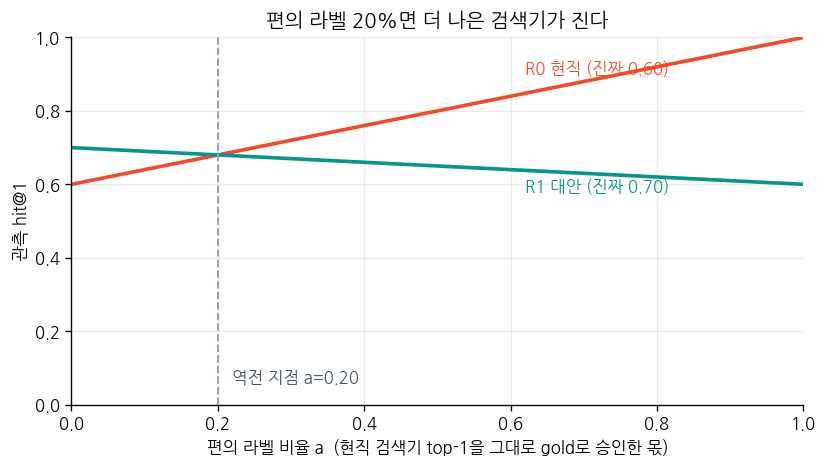

In [6]:
S0, S1, AGREE = 0.60, 0.70, 0.60          # 진짜 성능(R0, R1)과 top-1 일치율
shares = np.linspace(0, 1, 101)

obs_r0 = shares * 1.0 + (1 - shares) * S0     # 승인된 문항에서 R0는 정의상 정답
obs_r1 = shares * AGREE + (1 - shares) * S1
cross = float(shares[np.argmin(np.abs(obs_r0 - obs_r1))])

fig, ax = plt.subplots()
ax.plot(shares, obs_r0, color=C_MAIN, lw=2.2)
ax.plot(shares, obs_r1, color=C_SUB, lw=2.2)
ax.text(0.62, 0.90, "R0 현직 (진짜 0.60)", color=C_MAIN, fontsize=10)
ax.text(0.62, 0.58, "R1 대안 (진짜 0.70)", color=C_SUB, fontsize=10)

ax.axvline(cross, color=C_GRAY, ls="--", lw=1.2)
ax.text(cross + 0.02, 0.06, f"역전 지점 a={cross:.2f}", color="#475569", fontsize=10)

ax.set_xlabel("편의 라벨 비율 a  (현직 검색기 top-1을 그대로 gold로 승인한 몫)")
ax.set_ylabel("관측 hit@1")
ax.set_ylim(0, 1)
ax.set_xlim(0, 1)
ax.set_title(f"편의 라벨 {cross:.0%}면 더 나은 검색기가 진다")
plt.tight_layout()
plt.show()

라벨의 20%만 현직 검색기 top-1 승인으로 채워도 결론이 뒤집힌다. 더 나쁜 건 이 편향이
**자기 강화**된다는 점이다. R0가 이겼으므로 R0를 유지하고, 다음 라벨링에서도 R0의 top-1을
쓰게 되며, 그 셋에서 R0는 또 이긴다. 어느 단계에서도 부정이 없었는데 결론은 처음부터 정해져
있다.

이 곡선이 C4의 자연어화로 잡히지 않는다는 점이 중요하다. 질의를 아무리 자연스럽게 바꿔도
gold가 R0의 출력이면 R0는 계속 유리하다. 누수의 경로마다 다른 대응이 필요하다는 게 C4 §1
표의 요점이었고, 여기가 그 두 번째 행이다.

§4를 한 줄로 줄이면 이렇다. **평가셋에는 시스템의 성능만 들어 있는 게 아니라 그것을 만든
사람들의 판단과 절차가 함께 들어 있다.** 라벨 오류율은 격차를 압축하고, 일치율은 희소성 탓에
품질을 과장하고, 병합 규칙은 지표의 뜻을 바꾸고, 편의 라벨은 현직에게 유리하게 기울인다.
네 가지 모두 지표를 정교하게 고르는 것으로는 해결되지 않는다.

C1이 "지표는 질문"이고 C4가 "평가셋은 질문을 던지는 방식"이었다면, C5는 **"gold는 채점 기준이고
채점 기준도 누군가 쓴 것"**에 해당한다. 0단계 세 노트북이 함께 말하는 바는 하나다. 숫자를 보기
전에 그 숫자가 만들어진 경로를 먼저 적어야 한다.

## 5. 남은 질문

- 52문항 병합에 쓴 규칙이 union인지 다수결인지 확인해야 한다. union이라면 gold 복수 문항이
  존재한다는 뜻이고, C4가 넘긴 두 숙제 중 하나가 그 자리에서 닫힌다.
- gt 8건 교정이 **어느 방향**이었는지가 기록에 있어야 한다. gold 추가·제거·교체는 §4-1의 $q$를
  각각 다르게 만들며, 교체가 다수라면 편향 추정이 지금보다 커진다.
- 팀 라벨의 kappa를 실제로 잰 적이 없다. §4-2 기준으로 일치율만으로는 품질을 못 읽으므로,
  원 어노테이션이 남아 있다면 재계산할 값이 있다.
- gold를 만들 때 현직 검색기의 결과를 화면에 띄워두고 판정했는가? 그렇다면 §4-4의 $a$는 0이
  아니며, 그 값을 모르는 상태에서 검색기 A/B 결과를 신뢰할 수 없다.
- §4-2·4-3의 어노테이터 모델은 오류가 독립이라고 가정한다. 실제로는 같은 가이드라인을 읽은
  사람들이 **같은 방향으로** 틀리며, 그때 다수결은 오류를 걸러내지 못하고 증폭한다. 이 상관을
  넣으면 4-3의 결론이 얼마나 바뀌는지는 확인하지 않았다.
- 라벨 오류를 줄이는 비용과 문항 수를 늘리는 비용 중 어디에 먼저 쓸 것인가? §4-1의 격차 압축과
  C3의 표본 오차를 같은 단위로 놓아야 답이 나온다.

## 참고

- Cohen (1960), *A Coefficient of Agreement for Nominal Scales* — kappa 원논문
- Artstein & Poesio (2008), *Inter-Coder Agreement for Computational Linguistics*
- Northcutt, Athalye & Mueller (2021), *Pervasive Label Errors in Test Sets
  Destabilize ML Benchmarks*
- Voorhees (2000), *Variations in Relevance Judgments and the Measurement of
  Retrieval Effectiveness*
- 프로젝트: 52문항 병합 평가셋, gt 교정 이력, `eval.py`